In [36]:
import pandas as pd
from io import StringIO

data = """customer_id,tenure_months,avg_monthly_spend,transactions_last_3m,returns_last_3m,region,segment
1,3,40.0,5,0,North,New
2,24,120.0,18,1,South,Loyal
3,12,75.0,10,0,East,Regular
4,36,200.0,25,2,West,VIP
5,6,55.0,7,0,North,New
6,18,90.0,12,1,South,Regular
7,48,250.0,30,3,West,VIP
8,30,110.0,15,0,East,Loyal
9,9,60.0,8,0,North,New
10,20,95.0,11,1,South,Regular"""

df = pd.read_csv(StringIO(data))
df.head()

,customer_id,tenure_months,avg_monthly_spend,transactions_last_3m,returns_last_3m,region,segment
0,1,3,40.0,5,0,North,New
1,2,24,120.0,18,1,South,Loyal
2,3,12,75.0,10,0,East,Regular
3,4,36,200.0,25,2,West,VIP
4,5,6,55.0,7,0,North,New


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0    customer_id          10 non-null     int64  
 1   tenure_months         10 non-null     int64  
 2   avg_monthly_spend     10 non-null     float64
 3   transactions_last_3m  10 non-null     int64  
 4   returns_last_3m       10 non-null     int64  
 5   region                10 non-null     object 
 6   segment               10 non-null     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 692.0+ bytes


In [4]:
df.describe()

,customer_id,tenure_months,avg_monthly_spend,transactions_last_3m,returns_last_3m
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,20.600000,109.500000,14.100000,0.800000
std,3.02765,14.245467,66.727056,8.089087,1.032796
min,1.00000,3.000000,40.000000,5.000000,0.000000
25%,3.25000,9.750000,63.750000,8.500000,0.000000
50%,5.50000,19.000000,92.500000,11.500000,0.500000
75%,7.75000,28.500000,117.500000,17.250000,1.000000
max,10.00000,48.000000,250.000000,30.000000,3.000000


In [7]:
from sklearn import set_config
set_config(display="diagram")

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

numeric_features = ['tenure_months', 'avg_monthly_spend', 'transactions_last_3m', 'returns_last_3m']

X=df[numeric_features]

steps =[("Standard_Scaler",StandardScaler()),
        ("Classification",KMeans(n_clusters = 3))]

pipe1 = Pipeline(steps)

In [38]:
pipe1.fit(X)

Pipeline(steps=[('Standard_Scaler', StandardScaler()),
                ('Classification', KMeans(n_clusters=3))])

In [39]:
df["Cluster"] = pipe1["Classification"].labels_
df

,customer_id,tenure_months,avg_monthly_spend,transactions_last_3m,returns_last_3m,region,segment,Cluster
0,1,3,40.0,5,0,North,New,2
1,2,24,120.0,18,1,South,Loyal,0
2,3,12,75.0,10,0,East,Regular,2
3,4,36,200.0,25,2,West,VIP,1
4,5,6,55.0,7,0,North,New,2
5,6,18,90.0,12,1,South,Regular,0
6,7,48,250.0,30,3,West,VIP,1
7,8,30,110.0,15,0,East,Loyal,0
8,9,9,60.0,8,0,North,New,2
9,10,20,95.0,11,1,South,Regular,0


In [40]:
cluster_profiles = df.groupby("Cluster")[numeric_features].mean()
print(cluster_profiles)

         tenure_months  avg_monthly_spend  transactions_last_3m  \
Cluster                                                           
0                 23.0             103.75                  14.0   
1                 42.0             225.00                  27.5   
2                  7.5              57.50                   7.5   

         returns_last_3m  
Cluster                   
0                   0.75  
1                   2.50  
2                   0.00  


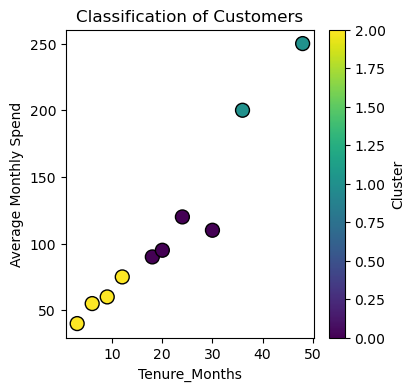

In [41]:
import matplotlib.pyplot as plt
plt.figure (figsize=(4,4))
plt.scatter(
    df['tenure_months'],
    df['avg_monthly_spend'],
    c = df['Cluster'],
    s=100,
    edgecolors='k'
)
plt.title("Classification of Customers")
plt.xlabel("Tenure_Months")
plt.ylabel("Average Monthly Spend")
plt.colorbar(label = "Cluster")
plt.show()

In [42]:
for cluster_id , row in cluster_profiles.iterrows():
    print("Cluster {}".format(cluster_id))
    if row['avg_monthly_spend']>=200 and row['transactions_last_3m'] >= 15:
        print("This cluster belonging to {} is a VIP and Highly Valuable".format(cluster_id))
    elif row['avg_monthly_spend']>=100 and row['transactions_last_3m'] >= 10:
        print("This cluster belonging to {} is a Non-VIP and Valuable".format(cluster_id))
    else:
        print("This cluster belonging to {} is a Average customer".format(cluster_id))

Cluster 0
This cluster belonging to 0 is a Non-VIP and Valuable
Cluster 1
This cluster belonging to 1 is a VIP and Highly Valuable
Cluster 2
This cluster belonging to 2 is a Average customer


In [44]:
import plotly.express as px

# Scatter plot with Plotly
fig = px.scatter(
    df,
    x="tenure_months",
    y="avg_monthly_spend",
    color="Cluster",          # color points by cluster
    hover_data=["customer_id","transactions_last_3m","returns_last_3m","region","segment"],
    title="Customer Clusters (KMeans)"
)

fig.show()